In [1]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd

# ================================
# 2. Load dataset
# ================================
df = pd.read_csv("cms_hospital_patient_satisfaction_2016.csv")

print("Original shape:", df.shape)

# ================================
# 3. Select useful columns
# ================================
df_clean = df[[
    'Facility Name',
    'State',
    'Hospital Type',
    'Emergency Services',
    'Hospital overall rating',
    'Patient Survey Star Rating',
    'HCAHPS Answer Percent',
    'HCAHPS Question'
]].copy()

# ================================
# 4. Replace invalid values
# ================================
df_clean = df_clean.replace(['Not Available', 'Not Applicable'], pd.NA)

# ================================
# 5. Convert to numeric
# ================================
numeric_cols = [
    'Hospital overall rating',
    'Patient Survey Star Rating',
    'HCAHPS Answer Percent'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ================================
# 6. Drop rows with missing key values
# ================================
df_clean = df_clean.dropna(subset=[
    'Hospital overall rating',
    'HCAHPS Answer Percent'
])

# (Optional) Keep Patient Survey Rating if available
# df_clean = df_clean.dropna(subset=['Patient Survey Star Rating'])

# ================================
# 7. Remove unrealistic values
# ================================
df_clean = df_clean[
    (df_clean['Hospital overall rating'] >= 1) &
    (df_clean['Hospital overall rating'] <= 5) &
    (df_clean['HCAHPS Answer Percent'] >= 0) &
    (df_clean['HCAHPS Answer Percent'] <= 100)
]

# ================================
# 8. Create additional KPI columns
# ================================

# Satisfaction category
df_clean['Satisfaction Level'] = pd.cut(
    df_clean['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

# ================================
# 9. Final check
# ================================
print("Cleaned shape:", df_clean.shape)
print(df_clean.describe())

# ================================
# 10. Export cleaned dataset
# ================================
df_clean.to_csv("cleaned_hospital_data.csv", index=False)

print("✅ Cleaned dataset saved as 'cleaned_hospital_data.csv'")

Original shape: (264385, 43)
Cleaned shape: (112864, 9)
       Hospital overall rating  Patient Survey Star Rating  \
count            112864.000000                         0.0   
mean                  3.062092                         NaN   
std                   0.815817                         NaN   
min                   1.000000                         NaN   
25%                   3.000000                         NaN   
50%                   3.000000                         NaN   
75%                   4.000000                         NaN   
max                   5.000000                         NaN   

       HCAHPS Answer Percent  
count          112864.000000  
mean               34.375000  
std                28.287726  
min                 0.000000  
25%                10.000000  
50%                22.000000  
75%                64.000000  
max               100.000000  
✅ Cleaned dataset saved as 'cleaned_hospital_data.csv'


In [2]:
# Create satisfaction category
df_clean['Satisfaction Level'] = pd.cut(
    df_clean['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

In [3]:
from scipy.stats import chi2_contingency

# Contingency table
table = pd.crosstab(df_clean['Hospital Type'], df_clean['Satisfaction Level'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("P-value:", p)

Chi2: 4678.713303530905
P-value: 0.0


In [4]:
# =========================================
# Import libraries
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

# =========================================
# 1. Load cleaned dataset
# =========================================
df = pd.read_csv("cleaned_hospital_data.csv")

# =========================================
# RQ1: Overall patient satisfaction
# =========================================
avg_satisfaction = df['Hospital overall rating'].mean()

print("RQ1: Average Satisfaction =", round(avg_satisfaction, 2))


# =========================================
# RQ2: Quality vs Satisfaction (Correlation)
# =========================================
corr, p_corr = pearsonr(
    df['HCAHPS Answer Percent'],
    df['Hospital overall rating']
)

print("\nRQ2: Correlation =", round(corr, 3))
print("P-value =", p_corr)


# =========================================
# RQ3: Emergency Services Impact (T-test)
# =========================================
group_yes = df[df['Emergency Services'] == 'Yes']['Hospital overall rating']
group_no = df[df['Emergency Services'] == 'No']['Hospital overall rating']

t_stat, p_ttest = ttest_ind(group_yes, group_no)

print("\nRQ3: T-test")
print("T-stat =", round(t_stat, 3))
print("P-value =", p_ttest)


# =========================================
# RQ4: Hospital Type vs Satisfaction (Chi2)
# =========================================
# Create satisfaction category
df['Satisfaction Level'] = pd.cut(
    df['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

table = pd.crosstab(df['Hospital Type'], df['Satisfaction Level'])

chi2, p_chi, dof, expected = chi2_contingency(table)

print("\nRQ4: Chi-square")
print("Chi2 =", chi2)
print("P-value =", p_chi)


# =========================================
# ARQ1: Best performing hospitals
# =========================================
top_hospitals = df.groupby('Facility Name')['Hospital overall rating'].mean().sort_values(ascending=False).head(5)

print("\nTop 5 Hospitals:")
print(top_hospitals)


# =========================================
# ARQ2: High satisfaction rate
# =========================================
high_sat_rate = np.mean(df['Hospital overall rating'] >= 4)

print("\nHigh Satisfaction Rate =", round(high_sat_rate, 2))


# =========================================
# ARQ3: Variation in satisfaction
# =========================================
std_dev = df['Hospital overall rating'].std()

print("\nStandard Deviation =", round(std_dev, 2))


# =========================================
# ARQ4: Detect inconsistencies
# =========================================
outliers = df[
    (df['HCAHPS Answer Percent'] > 80) &
    (df['Hospital overall rating'] < 3)
]

print("\nHospitals with high quality but low satisfaction:", len(outliers))

RQ1: Average Satisfaction = 3.06

RQ2: Correlation = 0.0
P-value = 0.9999999999999993

RQ3: T-test
T-stat = -15.826
P-value = 2.373354191430399e-56

RQ4: Chi-square
Chi2 = 4678.713303530905
P-value = 0.0

Top 5 Hospitals:
Facility Name
ADVENTIST LA GRANGE MEMORIAL HOSPITAL    5.0
ADVOCATE CONDELL MEDICAL CENTER          5.0
GORDON HOSPITAL                          5.0
ADVOCATE GOOD SHEPHERD HOSPITAL          5.0
UNITYPOINT HEALTH - MERITER              5.0
Name: Hospital overall rating, dtype: float64

High Satisfaction Rate = 0.29

Standard Deviation = 0.82

Hospitals with high quality but low satisfaction: 925


In [5]:
# =========================================
# 0. Import libraries
# =========================================
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

# =========================================
# 1. Load cleaned dataset
# =========================================
df = pd.read_csv("cleaned_hospital_data.csv")

# =========================================
# RQ1: Overall patient satisfaction
# =========================================
avg_satisfaction = df['Hospital overall rating'].mean()
print("RQ1: Average Satisfaction =", round(avg_satisfaction, 2))


# =========================================
# RQ2: Quality vs Satisfaction
# =========================================
corr, p_corr = pearsonr(
    df['HCAHPS Answer Percent'],
    df['Hospital overall rating']
)

print("\nRQ2: Correlation =", round(corr, 3))
print("RQ2: P-value =", p_corr)


# =========================================
# RQ3: Emergency Services impact
# =========================================
group_yes = df[df['Emergency Services'] == 'Yes']['Hospital overall rating']
group_no = df[df['Emergency Services'] == 'No']['Hospital overall rating']

t_stat, p_ttest = ttest_ind(group_yes, group_no)

print("\nRQ3: Emergency vs Non-Emergency")
print("T-stat =", round(t_stat, 3))
print("P-value =", p_ttest)


# =========================================
# RQ4: Hospital Type effect (Chi-square)
# =========================================
df['Satisfaction Level'] = pd.cut(
    df['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

table = pd.crosstab(df['Hospital Type'], df['Satisfaction Level'])

chi2, p_chi, dof, expected = chi2_contingency(table)

print("\nRQ4: Hospital Type vs Satisfaction")
print("Chi2 =", chi2)
print("P-value =", p_chi)


# =========================================
# ARQ1: Best aspects of care (HCAHPS)
# =========================================
top_questions = df.groupby('HCAHPS Question')['HCAHPS Answer Percent'] \
    .mean().sort_values(ascending=False).head(5)

print("\nARQ1: Top 5 Care Aspects")
print(top_questions)


# =========================================
# ARQ2: % of high satisfaction hospitals
# =========================================
high_sat_rate = np.mean(df['Hospital overall rating'] >= 4)

print("\nARQ2: High Satisfaction Rate =", round(high_sat_rate, 2))


# =========================================
# ARQ3: Consistency (correlation again)
# =========================================
print("\nARQ3: Consistency check (same as correlation)")
print("Correlation =", round(corr, 3))


# =========================================
# ARQ4: High quality but low satisfaction
# =========================================
outliers = df[
    (df['HCAHPS Answer Percent'] > 80) &
    (df['Hospital overall rating'] < 3)
]

print("\nARQ4: Hospitals with high quality but low satisfaction =", len(outliers))


# =========================================
# ARQ5: Variation in satisfaction
# =========================================
std_dev = df['Hospital overall rating'].std()

print("\nARQ5: Standard Deviation =", round(std_dev, 2))


# =========================================
# ARQ6: Chi-square significance (already computed)
# =========================================
if p_chi < 0.05:
    print("\nARQ6: Significant relationship between hospital type and satisfaction")
else:
    print("\nARQ6: No significant relationship")


# =========================================
# ARQ7: T-test significance (already computed)
# =========================================
if p_ttest < 0.05:
    print("ARQ7: Significant difference between emergency and non-emergency hospitals")
else:
    print("ARQ7: No significant difference")

RQ1: Average Satisfaction = 3.06

RQ2: Correlation = 0.0
RQ2: P-value = 0.9999999999999993

RQ3: Emergency vs Non-Emergency
T-stat = -15.826
P-value = 2.373354191430399e-56

RQ4: Hospital Type vs Satisfaction
Chi2 = 4678.713303530905
P-value = 0.0

ARQ1: Top 5 Care Aspects
HCAHPS Question
Patients who reported that YES, they were given information about what to do during their recovery at home    86.879217
Patients who reported that their doctors "Always" communicated well                                           81.040544
Patients who reported that their nurses "Always" communicated well                                            79.124468
Patients who reported that their room and bathroom were "Always" clean                                        72.828466
Patients who gave their hospital a rating of 9 or 10 on a scale from 0 (lowest) to 10 (highest)               71.058974
Name: HCAHPS Answer Percent, dtype: float64

ARQ2: High Satisfaction Rate = 0.29

ARQ3: Consistency check (sam

Average Patient Satisfaction: 3.06


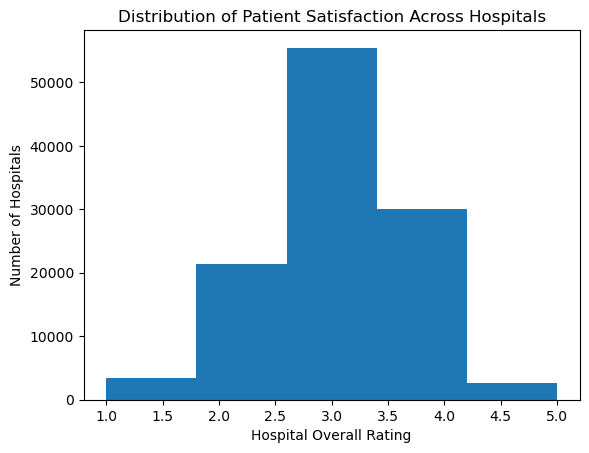

In [6]:
# =========================================
# 1. Import libraries
# =========================================
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 2. Load dataset
# =========================================
df = pd.read_csv("cleaned_hospital_data.csv")

# =========================================
# 3. Calculate average satisfaction
# =========================================
avg_satisfaction = df['Hospital overall rating'].mean()

print("Average Patient Satisfaction:", round(avg_satisfaction, 2))

# =========================================
# 4. Visualization (Histogram)
# =========================================
plt.figure()

plt.hist(df['Hospital overall rating'].dropna(), bins=5)

plt.title("Distribution of Patient Satisfaction Across Hospitals")
plt.xlabel("Hospital Overall Rating")
plt.ylabel("Number of Hospitals")

plt.show()

Correlation: 0.0
P-value: 0.9999999999999993


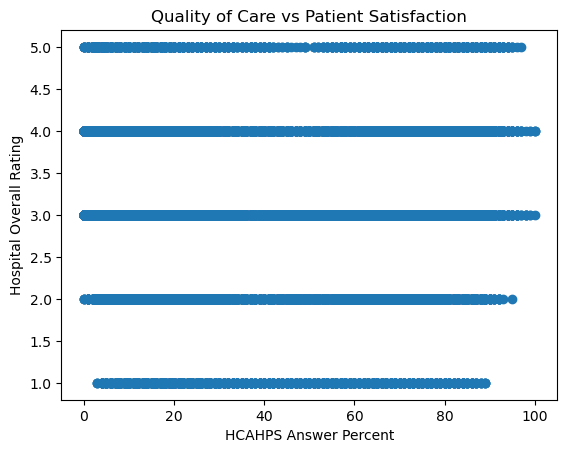

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = pd.read_csv("cleaned_hospital_data.csv")

# Correlation
corr, p_value = pearsonr(
    df['HCAHPS Answer Percent'],
    df['Hospital overall rating']
)

print("Correlation:", round(corr, 3))
print("P-value:", p_value)

# Scatter plot
plt.figure()
plt.scatter(df['HCAHPS Answer Percent'], df['Hospital overall rating'])

plt.title("Quality of Care vs Patient Satisfaction")
plt.xlabel("HCAHPS Answer Percent")
plt.ylabel("Hospital Overall Rating")

plt.show()

Mean (Emergency): 3.06
Mean (No Emergency): 3.32
P-value: 2.373354191430399e-56


<Figure size 640x480 with 0 Axes>

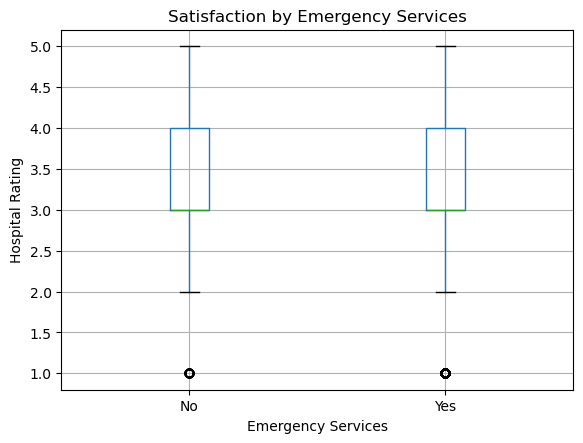

In [8]:
from scipy.stats import ttest_ind

# Split groups
group_yes = df[df['Emergency Services'] == 'Yes']['Hospital overall rating']
group_no = df[df['Emergency Services'] == 'No']['Hospital overall rating']

# T-test
t_stat, p_value = ttest_ind(group_yes, group_no)

print("Mean (Emergency):", round(group_yes.mean(), 2))
print("Mean (No Emergency):", round(group_no.mean(), 2))
print("P-value:", p_value)

# Boxplot
plt.figure()
df.boxplot(column='Hospital overall rating', by='Emergency Services')

plt.title("Satisfaction by Emergency Services")
plt.suptitle("")
plt.xlabel("Emergency Services")
plt.ylabel("Hospital Rating")

plt.show()

Hospital Type
Acute Care Hospitals         3.008435
Critical Access Hospitals    3.344583
Name: Hospital overall rating, dtype: float64


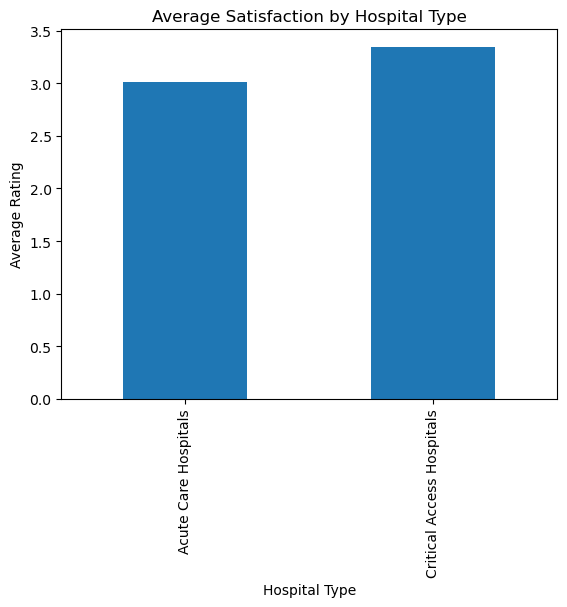

In [9]:
# Average satisfaction by hospital type
mean_by_type = df.groupby('Hospital Type')['Hospital overall rating'].mean()

print(mean_by_type)

# Bar chart
plt.figure()
mean_by_type.plot(kind='bar')

plt.title("Average Satisfaction by Hospital Type")
plt.xlabel("Hospital Type")
plt.ylabel("Average Rating")

plt.show()

In [10]:
from scipy.stats import chi2_contingency

# Create categories
df['Satisfaction Level'] = pd.cut(
    df['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

table = pd.crosstab(df['Hospital Type'], df['Satisfaction Level'])

chi2, p_value, _, _ = chi2_contingency(table)

print("Chi-square p-value:", p_value)

Chi-square p-value: 0.0


HCAHPS Question
Patients who reported that YES, they were given information about what to do during their recovery at home    86.879217
Patients who reported that their doctors "Always" communicated well                                           81.040544
Patients who reported that their nurses "Always" communicated well                                            79.124468
Patients who reported that their room and bathroom were "Always" clean                                        72.828466
Patients who gave their hospital a rating of 9 or 10 on a scale from 0 (lowest) to 10 (highest)               71.058974
Patients who reported YES, they would definitely recommend the hospital                                       70.786221
Patients who reported that their pain was "Always" well controlled                                            70.397505
Patients who reported that they "Always" received help as soon as they wanted                                 66.801815
Patients who reported th

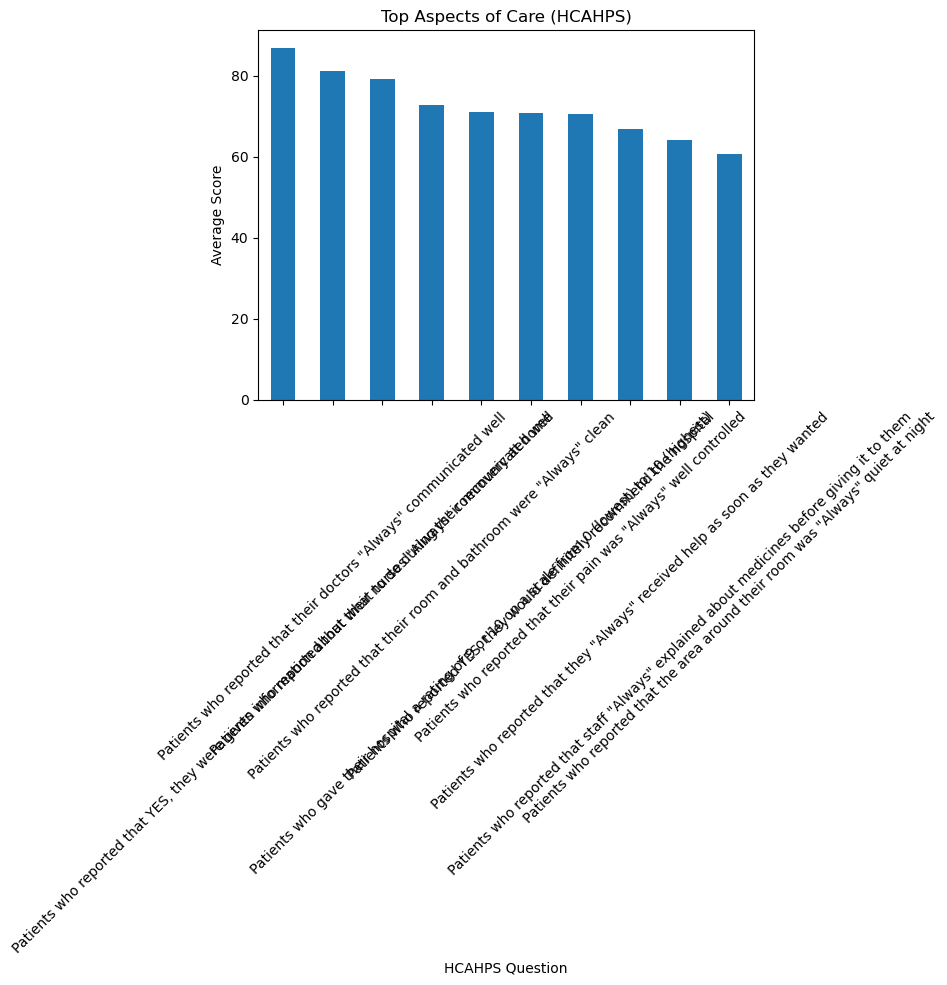

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_hospital_data.csv")

# Average score by question
question_scores = df.groupby('HCAHPS Question')['HCAHPS Answer Percent'].mean().sort_values(ascending=False)

print(question_scores.head(10))

# Plot
plt.figure()
question_scores.head(10).plot(kind='bar')

plt.title("Top Aspects of Care (HCAHPS)")
plt.xlabel("HCAHPS Question")
plt.ylabel("Average Score")

plt.xticks(rotation=45)
plt.show()

High Satisfaction Rate: 0.29


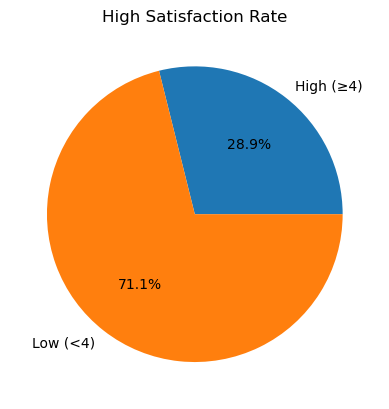

In [12]:
import numpy as np

high_rate = np.mean(df['Hospital overall rating'] >= 4)

print("High Satisfaction Rate:", round(high_rate, 2))

# Pie chart
plt.figure()
labels = ['High (≥4)', 'Low (<4)']
sizes = [high_rate, 1 - high_rate]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("High Satisfaction Rate")
plt.show()

Correlation: 0.0
P-value: 0.9999999999999993


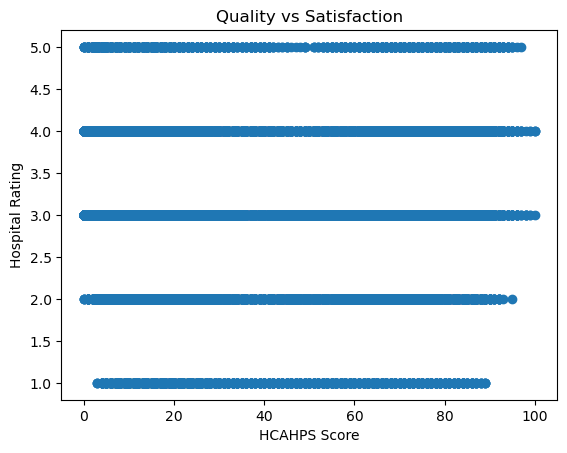

In [13]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['HCAHPS Answer Percent'], df['Hospital overall rating'])

print("Correlation:", round(corr, 3))
print("P-value:", p)

# Scatter
plt.figure()
plt.scatter(df['HCAHPS Answer Percent'], df['Hospital overall rating'])

plt.title("Quality vs Satisfaction")
plt.xlabel("HCAHPS Score")
plt.ylabel("Hospital Rating")

plt.show()

Number of inconsistent hospitals: 925


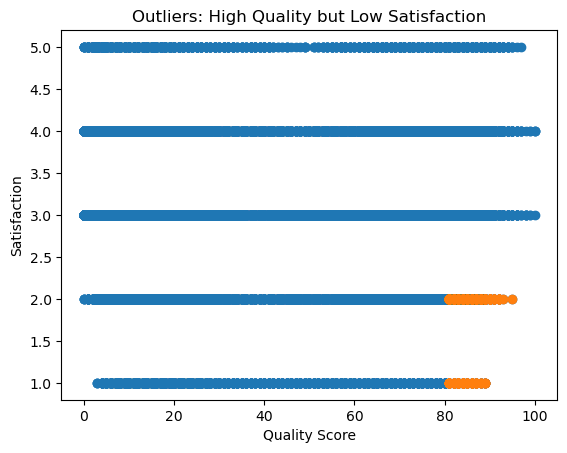

In [14]:
outliers = df[
    (df['HCAHPS Answer Percent'] > 80) &
    (df['Hospital overall rating'] < 3)
]

print("Number of inconsistent hospitals:", len(outliers))

# Highlight in scatter
plt.figure()

plt.scatter(df['HCAHPS Answer Percent'], df['Hospital overall rating'])
plt.scatter(outliers['HCAHPS Answer Percent'], outliers['Hospital overall rating'])

plt.title("Outliers: High Quality but Low Satisfaction")
plt.xlabel("Quality Score")
plt.ylabel("Satisfaction")

plt.show()

Standard Deviation: 0.82


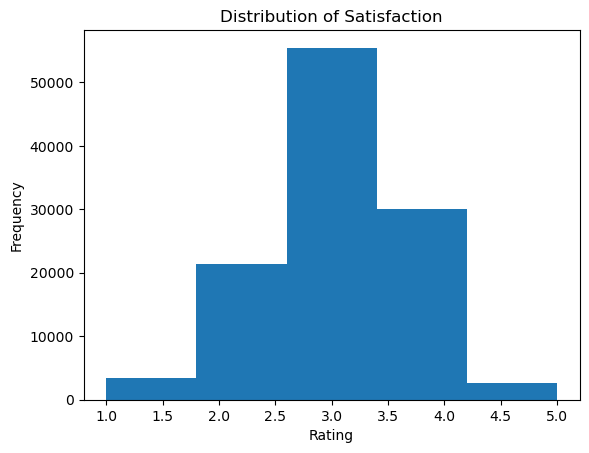

In [15]:
std_dev = df['Hospital overall rating'].std()

print("Standard Deviation:", round(std_dev, 2))

# Histogram
plt.figure()
plt.hist(df['Hospital overall rating'], bins=5)

plt.title("Distribution of Satisfaction")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

Chi-square p-value: 0.0


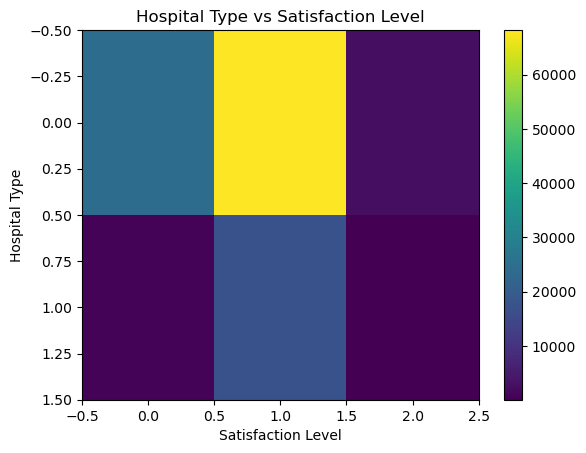

In [16]:
from scipy.stats import chi2_contingency

df['Satisfaction Level'] = pd.cut(
    df['Hospital overall rating'],
    bins=[0, 2, 4, 5],
    labels=['Low', 'Medium', 'High']
)

table = pd.crosstab(df['Hospital Type'], df['Satisfaction Level'])

chi2, p, _, _ = chi2_contingency(table)

print("Chi-square p-value:", p)

# Heatmap-like plot
plt.figure()
plt.imshow(table, aspect='auto')
plt.colorbar()

plt.title("Hospital Type vs Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Hospital Type")

plt.show()

P-value: 2.373354191430399e-56


<Figure size 640x480 with 0 Axes>

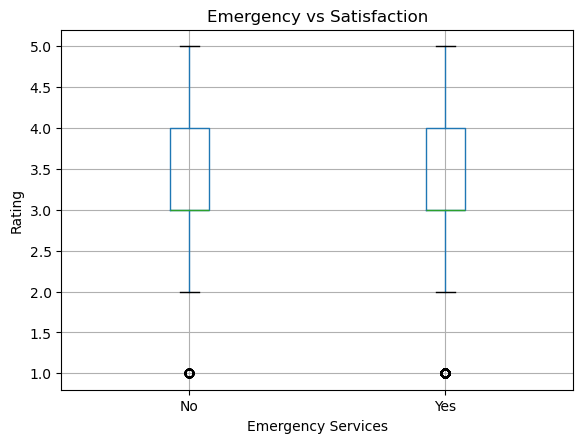

In [17]:
from scipy.stats import ttest_ind

group_yes = df[df['Emergency Services'] == 'Yes']['Hospital overall rating']
group_no = df[df['Emergency Services'] == 'No']['Hospital overall rating']

t_stat, p = ttest_ind(group_yes, group_no)

print("P-value:", p)

# Boxplot
plt.figure()
df.boxplot(column='Hospital overall rating', by='Emergency Services')

plt.title("Emergency vs Satisfaction")
plt.suptitle("")
plt.xlabel("Emergency Services")
plt.ylabel("Rating")

plt.show()